In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================================================
# 1. Ler a malha municipal do IBGE
# Ajuste o caminho para o seu arquivo
# ============================================================
shapefile_path = "C:\\Users\\IFMT\\Downloads\\mapas\\MT_Municipios_2025.shp"
gdf = gpd.read_file(shapefile_path)

print("Colunas disponíveis:")
print(gdf.columns.tolist())
print("\nCRS original:", gdf.crs)


Colunas disponíveis:
['CD_MUN', 'NM_MUN', 'CD_RGI', 'NM_RGI', 'CD_RGINT', 'NM_RGINT', 'CD_UF', 'NM_UF', 'SIGLA_UF', 'CD_REGIAO', 'NM_REGIAO', 'SIGLA_RG', 'CD_CONCURB', 'NM_CONCURB', 'AREA_KM2', 'geometry']

CRS original: EPSG:4674


In [2]:

# ============================================================
# 2. Filtrar apenas os municípios de Mato Grosso
# Tenta identificar automaticamente a coluna de UF
# ============================================================
if "SIGLA_UF" in gdf.columns:
    mt = gdf[gdf["SIGLA_UF"] == "MT"].copy()
elif "CD_UF" in gdf.columns:
    mt = gdf[gdf["CD_UF"].astype(str).str[:2] == "51"].copy()
elif "UF" in gdf.columns:
    mt = gdf[gdf["UF"] == "MT"].copy()
else:
    raise ValueError(
        "Não foi possível identificar a coluna da UF. "
        "Verifique o nome das colunas do arquivo."
    )

print(f"\nQuantidade de municípios de MT: {len(mt)}")




Quantidade de municípios de MT: 142


In [4]:
# ============================================================
# 3. Reprojetar para um CRS projetado adequado
# Isso melhora o cálculo de centróides e distâncias
# ============================================================
mt = mt.to_crs(mt.estimate_utm_crs())

# ============================================================
# 4. Obter o polígono do estado e seu centróide
# ============================================================
estado_mt = mt.union_all()
centro_estado = estado_mt.centroid
cx, cy = centro_estado.x, centro_estado.y


In [5]:

# ============================================================
# 5. Calcular centróide de cada município
# ============================================================
mt["centroide"] = mt.geometry.centroid
mt["x"] = mt["centroide"].x
mt["y"] = mt["centroide"].y

# Deslocamento em relação ao centro do estado
mt["dx"] = mt["x"] - cx
mt["dy"] = mt["y"] - cy



In [6]:
# ============================================================
# 6. Classificar em Norte, Sul, Leste e Oeste
# Regra:
# - se |dy| >= |dx| -> Norte ou Sul
# - senão -> Leste ou Oeste
# ============================================================
def classificar_regiao(row):
    dx = row["dx"]
    dy = row["dy"]

    if abs(dy) >= abs(dx):
        return "Norte" if dy >= 0 else "Sul"
    else:
        return "Leste" if dx >= 0 else "Oeste"

mt["regiao_mt"] = mt.apply(classificar_regiao, axis=1)

print("\nMunicípios por região:")
print(mt["regiao_mt"].value_counts())




Municípios por região:
regiao_mt
Sul      55
Leste    34
Oeste    27
Norte    26
Name: count, dtype: int64


In [7]:
# ============================================================
# 7. Definir cores
# ============================================================
cores = {
    "Norte": "#1f78b4",   # azul
    "Sul":   "#33a02c",   # verde
    "Leste": "#ff7f00",   # laranja
    "Oeste": "#e31a1c"    # vermelho
}

mt["cor"] = mt["regiao_mt"].map(cores)



In [8]:
# ============================================================
# 8. Criar camadas dissolvidas por região (opcional)
# Útil para desenhar contornos das regiões
# ============================================================
regioes = mt.dissolve(by="regiao_mt").reset_index()



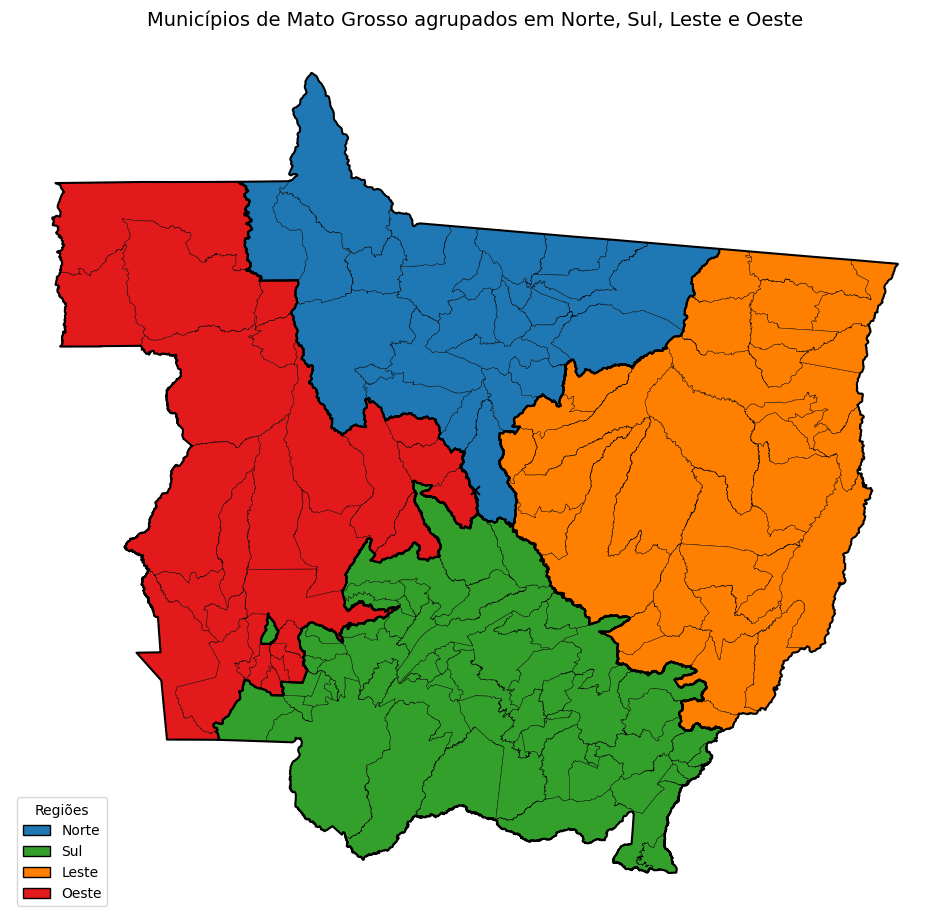

ValueError: GeoDataFrame contains multiple geometry columns but GeoDataFrame.to_file supports only a single geometry column. Use a GeoDataFrame.to_parquet or GeoDataFrame.to_feather, drop additional geometry columns or convert them to a supported format like a well-known text (WKT) using `GeoSeries.to_wkt()`.

In [9]:
# ============================================================
# 9. Plotar o mapa
# ============================================================
fig, ax = plt.subplots(figsize=(12, 12))

# Municípios coloridos
mt.plot(
    ax=ax,
    color=mt["cor"],
    edgecolor="black",
    linewidth=0.3
)

# Contorno das regiões
regioes.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5
)

# Centro do estado
ax.scatter(cx, cy, color="black", s=40, marker="x", label="Centro do estado")

# Título
ax.set_title("Municípios de Mato Grosso agrupados em Norte, Sul, Leste e Oeste", fontsize=14)
ax.axis("off")

# Legenda manual
legend_elements = [
    Patch(facecolor=cores["Norte"], edgecolor="black", label="Norte"),
    Patch(facecolor=cores["Sul"], edgecolor="black", label="Sul"),
    Patch(facecolor=cores["Leste"], edgecolor="black", label="Leste"),
    Patch(facecolor=cores["Oeste"], edgecolor="black", label="Oeste"),
]
ax.legend(handles=legend_elements, title="Regiões", loc="lower left")

plt.show()

# ============================================================
# 10. Salvar resultado
# ============================================================
mt.to_file("municipios_mt_regioes.geojson", driver="GeoJSON")
print("\nArquivo salvo: municipios_mt_regioes.geojson")